In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [3]:
df = pd.read_csv('../data/raw/서울시 상권분석서비스(추정매출-상권).csv', encoding='cp949')
df.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20254,U,관광특구,3001496,강남 마이스 관광특구,CS300036,조명용품,185366106,484,185366106,...,242,0,0,484,0,0,0,0,0,484
1,20254,U,관광특구,3001496,강남 마이스 관광특구,CS300032,가전제품,48955198,130,0,...,130,0,0,130,0,0,130,0,0,0
2,20254,U,관광특구,3001496,강남 마이스 관광특구,CS300031,가구,4175008925,3031,2471268906,...,669,0,916,2080,0,70,176,422,564,1763
3,20254,U,관광특구,3001496,강남 마이스 관광특구,CS300028,화초,755551967,6197,731348440,...,1809,6,2550,3096,103,1206,2000,1079,800,460
4,20254,U,관광특구,3001496,강남 마이스 관광특구,CS300026,완구,2258493446,52021,1319380913,...,19835,1471,18685,33336,917,12421,17266,16772,2913,1732


In [18]:
geo_shp

,TRDAR_SE_C,TRDAR_SE_1,TRDAR_CD,TRDAR_CD_N,XCNTS_VALU,YDNTS_VALU,SIGNGU_CD,SIGNGU_CD_,ADSTRD_CD,ADSTRD_CD_,RELM_AR,geometry
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093.0,453418.0,11110,종로구,11110515,청운효자동,149264.0,"POLYGON ((196955.842 453722.114, 196958.669 45..."
1,U,관광특구,3001494,종로·청계 관광특구,199796.0,452274.0,11110,종로구,11110615,종로1·2·3·4가동,653127.0,"POLYGON ((201385.38 452513.725, 201385.284 452..."
2,R,전통시장,3130021,신설종합시장,201854.0,452569.0,11110,종로구,11110710,숭인2동,9800.0,"POLYGON ((201937.121 452552.083, 201872.576 45..."
3,R,전통시장,3130002,세종마을음식문화거리(금천교시장),197423.0,453030.0,11110,종로구,11110530,사직동,49557.0,"POLYGON ((197550.67 453079.887, 197554.026 453..."
4,R,전통시장,3130001,통인시장,197351.0,453449.0,11110,종로구,11110515,청운효자동,38280.0,"POLYGON ((197428.009 453548.216, 197436.697 45..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1645,R,전통시장,3130322,고분다리전통시장,211771.0,449208.0,11740,강동구,11740620,천호3동,20499.0,"POLYGON ((211759.866 449221.074, 211779.452 44..."
1646,R,전통시장,3130323,둔촌역전통시장,211868.0,447599.0,11740,강동구,11740660,성내3동,36613.0,"POLYGON ((211924.717 447688.584, 211931.962 44..."
1647,R,전통시장,3130324,길동복조리시장,212690.0,448844.0,11740,강동구,11740685,길동,29464.0,"POLYGON ((212814.498 448972.661, 212804.818 44..."
1648,R,전통시장,3130325,명일전통시장,212839.0,449976.0,11740,강동구,11740530,명일1동,27547.0,"POLYGON ((212922.264 449886.083, 212922.218 44..."


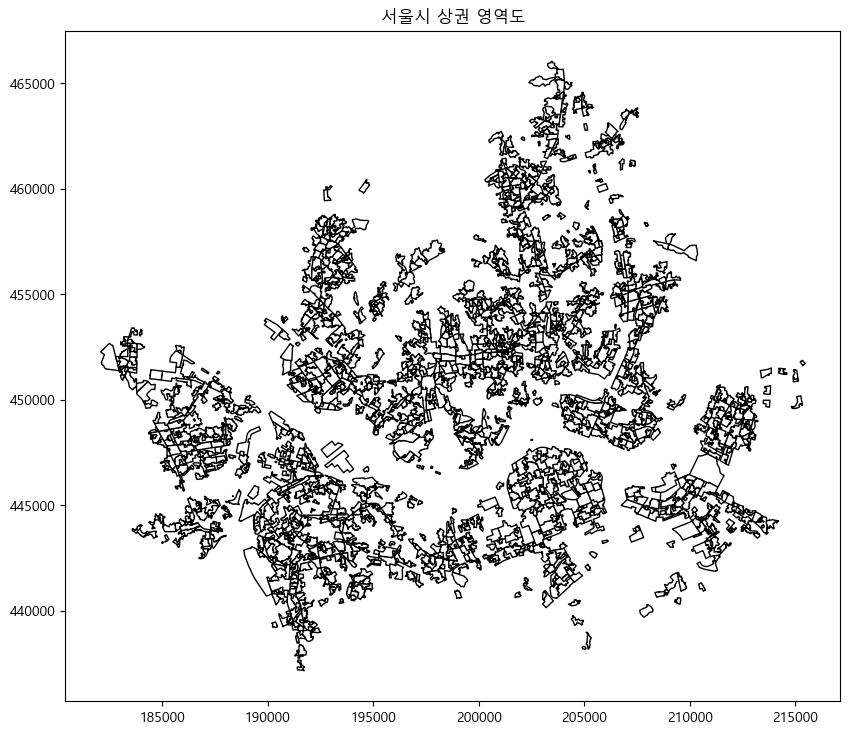

In [43]:
geo_shp = gpd.read_file('../data/raw/서울시 상권분석서비스(영역-상권)/서울시 상권분석서비스(영역-상권).shp', encoding = 'utf-8')
geo_shp.to_crs(epsg = 4326)
geo_shp.plot(figsize=(10, 10), color='white', edgecolor='black')
plt.title('서울시 상권 영역도')
plt.show()

In [29]:
df['상권_코드'] = df['상권_코드'].astype(str)
merged_gdf = geo_shp.merge(df, left_on = 'TRDAR_CD', right_on= '상권_코드')

In [33]:
merged_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 85732 entries, 0 to 85731
Data columns (total 67 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   TRDAR_SE_C       85732 non-null  str     
 1   TRDAR_SE_1       85732 non-null  str     
 2   TRDAR_CD         85732 non-null  str     
 3   TRDAR_CD_N       85732 non-null  str     
 4   XCNTS_VALU       85732 non-null  float64 
 5   YDNTS_VALU       85732 non-null  float64 
 6   SIGNGU_CD        85732 non-null  str     
 7   SIGNGU_CD_       85732 non-null  str     
 8   ADSTRD_CD        85732 non-null  str     
 9   ADSTRD_CD_       85732 non-null  str     
 10  RELM_AR          85732 non-null  float64 
 11  geometry         85732 non-null  geometry
 12  기준_년분기_코드        85732 non-null  int64   
 13  상권_구분_코드         85732 non-null  str     
 14  상권_구분_코드_명       85732 non-null  str     
 15  상권_코드            85732 non-null  str     
 16  상권_코드_명          85732 non-null 

In [36]:
merged_gdf['당월_매출_금액']

0          36379537
1           9634738
2           6765221
3          88508722
4          68248733
            ...    
85727    5927291009
85728      77925343
85729     176820781
85730     139782290
85731    1656406224
Name: 당월_매출_금액, Length: 85732, dtype: int64

In [37]:
# 1. 결측치(빈칸)가 몇 개인지 확인
print("결측치 개수:", merged_gdf['당월_매출_금액'].isna().sum())

# 2. 데이터의 최대/최소, 평균 등 분포 확인
print(merged_gdf['당월_매출_금액'].describe())

결측치 개수: 0
count    8.573200e+04
mean     1.080789e+09
std      9.191795e+09
min      3.100000e+01
25%      4.583811e+07
50%      1.721363e+08
75%      6.159625e+08
max      1.148994e+12
Name: 당월_매출_금액, dtype: float64


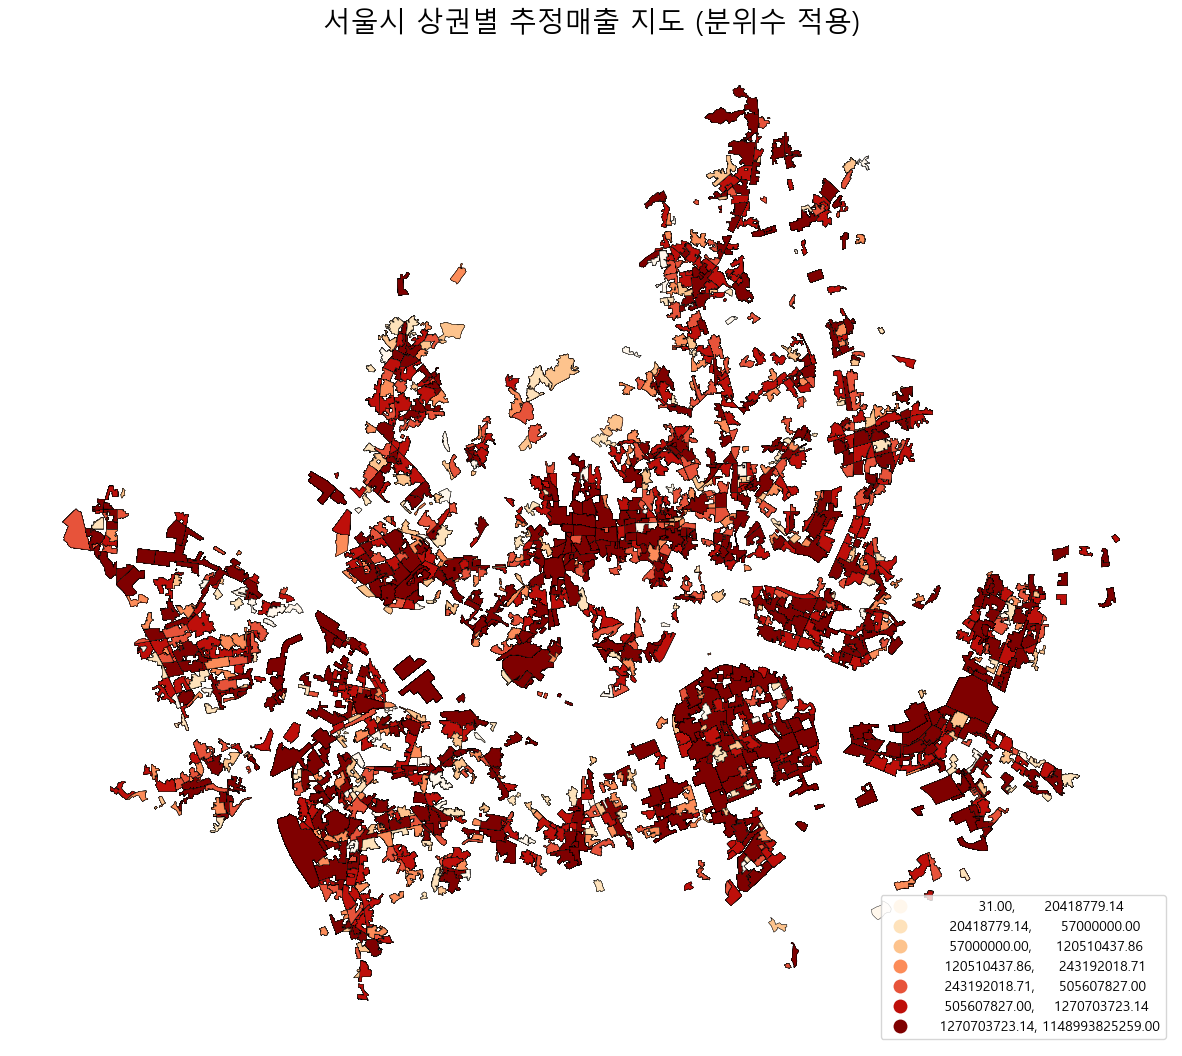

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

merged_gdf.plot(
    column='당월_매출_금액', 
    scheme='quantiles',      # 🌟 핵심: 절대 금액이 아니라 '상위 % (순위)' 단위로 색을 나눔
    k=7,                     # 색상을 7단계로 쪼갬
    ax=ax,
    legend=True,
    legend_kwds={'loc': 'lower right'}, # 범례 위치 조정
    cmap='OrRd',             # 연한 주황 -> 진한 빨강
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey'} # 매출 데이터가 없는 구역은 연회색
)

plt.title('서울시 상권별 추정매출 지도 (분위수 적용)', fontsize=20)
plt.axis('off')
plt.show()